In [2]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [3]:
def load_pickle(file='data0.pickle'):
    with open(f'./Data/_4GB/{file}', 'rb') as f:
        data = pickle.load(f, encoding='latin1')  # latin1 for dictionary
    return data

In [4]:
data = load_pickle()

In [7]:
data['y_test']

array([25, 11, 38, ...,  8, 33, 10], dtype=uint8)

# Number of samples from each label in each training, validating, and testing set

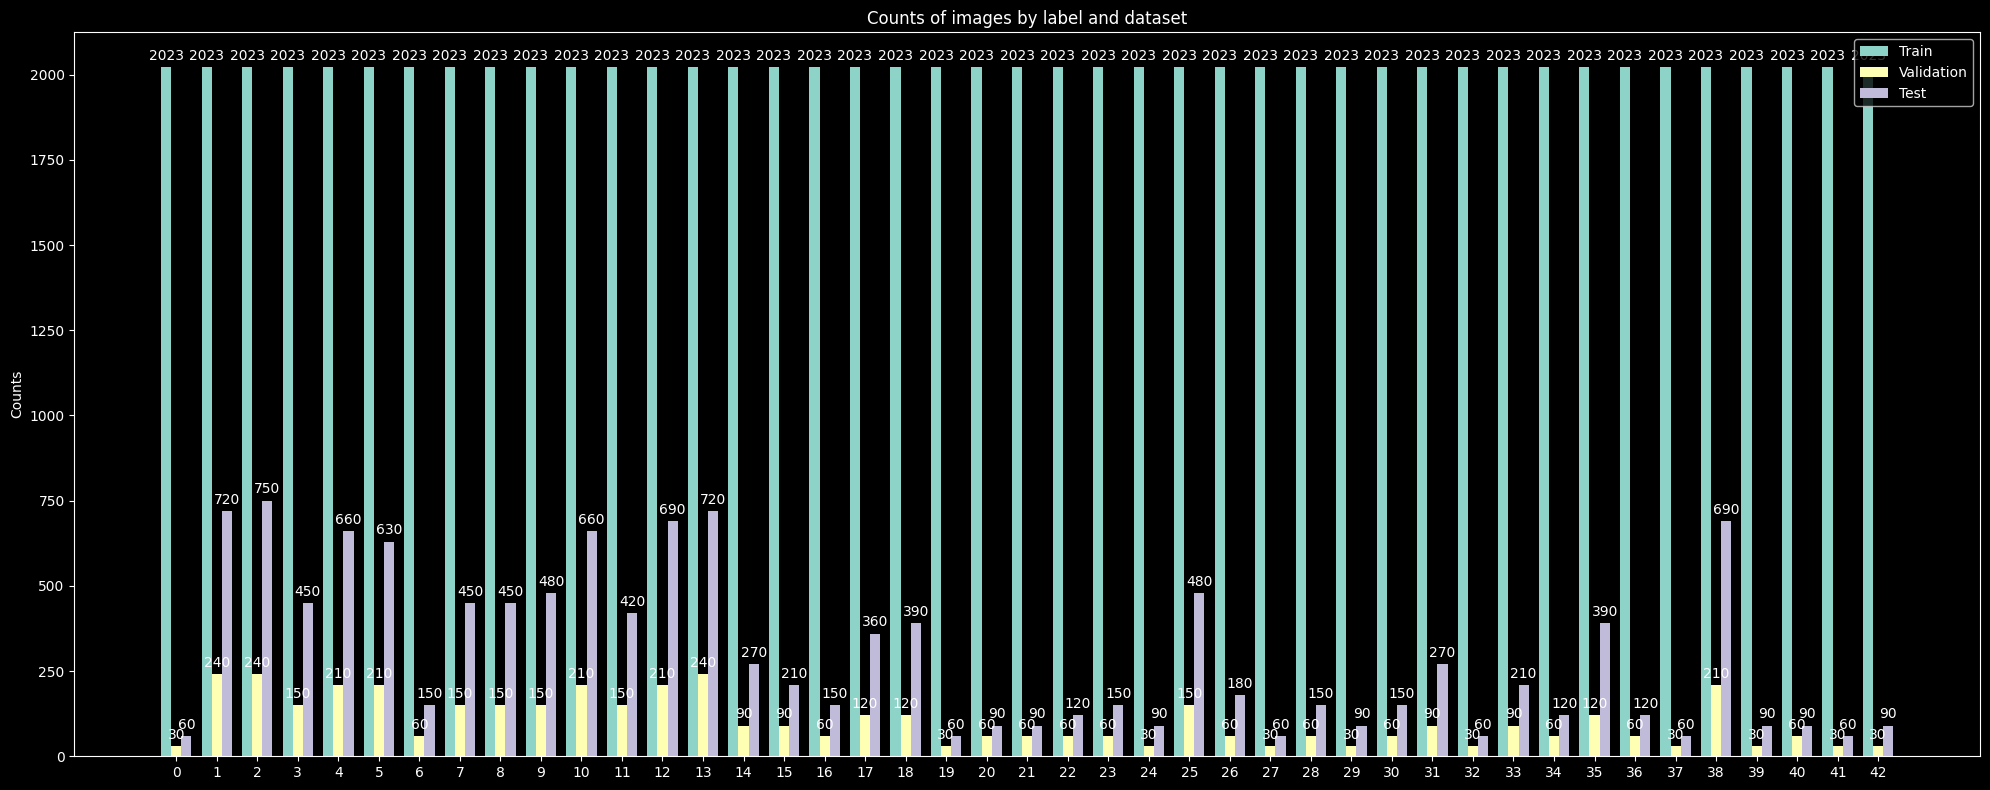

In [9]:
# Count the occurrences of each label in each set.
train_counts = np.bincount(data['y_train'], minlength=len(data['labels']))
val_counts = np.bincount(data['y_validation'], minlength=len(data['labels']))
test_counts = np.bincount(data['y_test'], minlength=len(data['labels']))

# Set up the plot
# Assuming labels are sequential integers
labels = np.arange(len(data['labels']))
x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(20, 8))
rects1 = ax.bar(x - width, train_counts, width, label='Train')
rects2 = ax.bar(x, val_counts, width, label='Validation')
rects3 = ax.bar(x + width, test_counts, width, label='Test')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Counts')
ax.set_title('Counts of images by label and dataset')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Function to automatically label the bars with their height value


def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')


autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()

plt.show()

Unprocessed RGB images


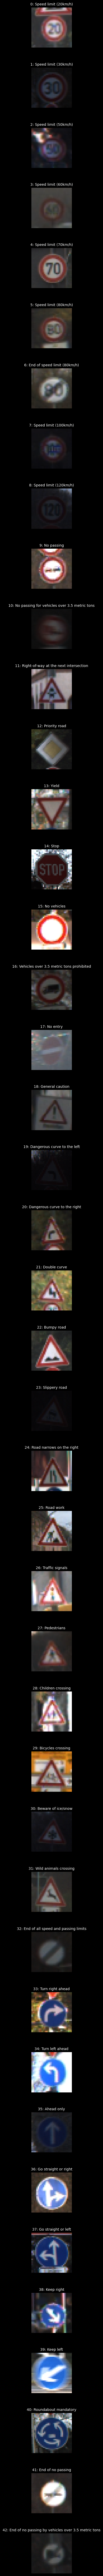

In [5]:
import matplotlib.pyplot as plt
import numpy as np


def plot_one_sign_per_label(x, y, labels, is_grayscale=False):
    '''
    x: numpy array of shape (n_samples, n_channels, height, width)
    y: numpy array of shape (n_samples,)
    labels: list of strings with length n_classes
    is_grayscale: boolean indicating whether the images are greyscale or RGB
    
    This function plots one image per label, with each image in its own row.
    '''
    n_classes = len(labels)
    fig, axes = plt.subplots(n_classes, 1, figsize=(
        5, 3*n_classes))  # Adjust the figsize if necessary
    plt.subplots_adjust(hspace=0.5, wspace=0.1)

    # If there's only one class, matplotlib doesn't return an array of axes
    if n_classes == 1:
        axes = [axes]

    for class_index in range(n_classes):
        images = x[y == class_index]
        if len(images) > 0:
            image_index = 0  # Just pick the first image for simplicity

            if is_grayscale:
                # If grayscale, remove the single-channel dimension
                image = images[image_index].squeeze()
                axes[class_index].imshow(image.astype('uint8'), cmap='gray')
            else:
                # If RGB, transpose the image to channel-last format
                image = images[image_index].transpose(1, 2, 0)
                axes[class_index].imshow(image.astype('uint8'))

            axes[class_index].set_title(f"{class_index}: {labels[class_index]}", fontsize=10)
            axes[class_index].axis('off')
        else:
            # If no image is found for the class, hide the axis
            axes[class_index].axis('off')

    plt.show()

# Example usage (assuming you have a function load_pickle to load your dataset):
print("Unprocessed RGB images")
data = load_pickle('data0.pickle')
plot_one_sign_per_label(
    x=data['x_test'],
    y=data['y_test'],
    labels=data['labels'],
    is_grayscale=False
)
# print("Unprocessed Grayscale images")
# data = load_pickle('data4.pickle')
# plot_one_sign_per_label(
#     x=data['x_test'],
#     y=data['y_test'],
#     labels=data['labels'],
#     is_grayscale=True
# )